In [ ]:
#Preprocessesing the dataset


import json
import random
import re


INPUT_FILE = "/content/orignal_dataset_custom_final.json"
OUTPUT_FILE = "orignal_processed_dataset_custom_final.json"

MIN_SAMPLES = 120
MAX_SAMPLES = 180


CONVERSATIONAL = {
    "greeting", "farewell", "thankyou", "not_happy"
}

FUNCTIONAL = {
    "login", "sign_up", "home_screen",
    "request_service_screen", "post_service_screen",
    "drawer", "rating_review", "my_account_profile",
    "internal_chatbot", "external_chatbot",
    "certified", "service_availability"
}


FUNCTIONAL_TEMPLATES = [
    "open {text}",
    "go to {text}",
    "navigate to {text}",
    "show me {text}",
    "where is {text}",
    "how to access {text}",
    "i want {text}",
    "take me to {text}",
    "help me open {text}",
    "i need {text}",
    "display {text}",
    "can you open {text}",
    "bring me to {text}",
    "access {text}",
]


SERVICE_TEMPLATES = [
    "i need a {service}",
    "i need {service}",
    "looking for a {service}",
    "find me a {service}",
    "i want to hire a {service}",
    "need {service} urgently",
    "urgent {service} required",
    "can you send a {service}",
    "book a {service}",
    "call a {service}",
    "require {service} service",
    "any {service} available",
    "best {service} near me",
    "professional {service} needed",
    "i need help with {service}",
    "please arrange a {service}",
    "get me a {service}",
    "hire a {service} now",
    "i want {service} service",
    "someone for {service}",
    "i am looking for {service}",
    "need expert {service}",
    "is there a {service} nearby",
    "send {service} to my location",
]


def normalize(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    return text


def slight_variation(text):
    variations = [
        text,
        "please " + text,
        text + " please",
        "can you " + text,
        "i want to " + text,
        text + " urgently",
        "please help " + text,
    ]
    return random.choice(variations)


def process_intent(intent_name, texts):
    intent = intent_name.lower()


    clean = list(set(normalize(t) for t in texts if t.strip()))
    augmented = set(clean)

    if intent in CONVERSATIONAL:
        return list(augmented)


    elif intent in FUNCTIONAL:
        base = intent.replace("_", " ")
        needed = max(0, MIN_SAMPLES - len(augmented))

        for _ in range(needed):
            template = random.choice(FUNCTIONAL_TEMPLATES)
            new_text = template.format(text=base)

            augmented.add(new_text)
            augmented.add(slight_variation(new_text))

        return list(augmented)[:MAX_SAMPLES]

    else:
        service = intent.replace("_", " ")
        needed = max(0, MIN_SAMPLES - len(augmented))

        for _ in range(needed):
            template = random.choice(SERVICE_TEMPLATES)
            new_text = template.format(service=service)

            augmented.add(new_text)
            augmented.add(slight_variation(new_text))

        return list(augmented)[:MAX_SAMPLES]


def main():
    with open(INPUT_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)

    total = 0

    for intent in data["intents"]:
        name = intent["intent"]
        texts = intent["text"]

        processed = process_intent(name, texts)
        intent["text"] = processed

        print(f"{name:30} → {len(processed)} samples")
        total += len(processed)

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

    print("\n PREPROCESSING DONE")
    print(f"Total samples: {total}")
    print(f"Saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

Farewell                       → 53 samples
Greeting                       → 59 samples
ThankYou                       → 54 samples
not_happy                      → 44 samples
login                          → 100 samples
sign_up                        → 102 samples
home_screen                    → 93 samples
internal_chatbot               → 90 samples
external_chatbot               → 93 samples
my_account_profile             → 95 samples
request_service_screen         → 98 samples
post_service_screen            → 106 samples
drawer                         → 103 samples
rating_review                  → 88 samples
certified                      → 97 samples
service_availability           → 99 samples
house_cleaning                 → 123 samples
electrician                    → 128 samples
plumber                        → 127 samples
carpenter                      → 123 samples
barber                         → 120 samples
automotive                     → 124 samples
pest_control          

In [ ]:
#Removing bad sentences that left in first preprocessesing


import json

INPUT_FILE = "/content/orignal_processed_dataset_custom_final.json"
OUTPUT_FILE = "/content/orignal_processed_dataset_custom_final.json"  # overwrite SAME file

def is_bad_sentence(text):
    t = text.lower().strip()


    bad_patterns = [
        "can you can you",
        "help help",
        "i want to can you",
        "i want to i need",
        "can you i want",
    ]


    words = t.split()
    if len(words) >= 2:
        for i in range(len(words) - 1):
            if words[i] == words[i + 1]:
                return True


    for p in bad_patterns:
        if p in t:
            return True

    return False


with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

total_removed = 0

for intent in data["intents"]:
    original = intent["text"]

    cleaned = []
    removed_local = 0

    for t in original:
        if not is_bad_sentence(t):
            cleaned.append(t)
        else:
            removed_local += 1


    cleaned = list(set(cleaned))

    intent["text"] = cleaned

    total_removed += removed_local

    print(f"{intent['intent']:25} | removed: {removed_local} | final: {len(cleaned)}")


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print("\n CLEANING DONE (SAFE MODE)")
print("Total removed:", total_removed)

Farewell                  | removed: 1 | final: 52
Greeting                  | removed: 0 | final: 59
ThankYou                  | removed: 0 | final: 54
not_happy                 | removed: 0 | final: 44
login                     | removed: 2 | final: 98
sign_up                   | removed: 4 | final: 98
home_screen               | removed: 4 | final: 89
internal_chatbot          | removed: 2 | final: 88
external_chatbot          | removed: 4 | final: 89
my_account_profile        | removed: 2 | final: 93
request_service_screen    | removed: 4 | final: 94
post_service_screen       | removed: 1 | final: 105
drawer                    | removed: 3 | final: 100
rating_review             | removed: 4 | final: 84
certified                 | removed: 3 | final: 94
service_availability      | removed: 2 | final: 97
house_cleaning            | removed: 2 | final: 121
electrician               | removed: 2 | final: 126
plumber                   | removed: 5 | final: 122
carpenter                 

In [ ]:
#preprocessesing for Model



import json
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


DATA_PATH = "/content/orignal_processed_dataset_custom_final.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

texts = []
labels = []

for intent in data["intents"]:
    for t in intent["text"]:
        texts.append(t)
        labels.append(intent["intent"])

print(" Total samples:", len(texts))



VOCAB_SIZE = 5000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

MAX_LEN = 20
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

print(" Example padded sequence:", padded[0])



label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

num_classes = len(set(encoded_labels))
print(" Total intents:", num_classes)



X_train, X_test, y_train, y_test = train_test_split(
    padded,
    encoded_labels,
    test_size=0.2,
    random_state=42
)

print(" Train size:", len(X_train))
print(" Test size:", len(X_test))

✅ Total samples: 3729
✅ Example padded sequence: [175   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
✅ Total intents: 36
✅ Train size: 2983
✅ Test size: 746


In [ ]:
#Model


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense


model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()



history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_test, y_test)
)


loss, acc = model.evaluate(X_test, y_test)
print(" Test Accuracy:", acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0392 - loss: 3.5708 - val_accuracy: 0.0992 - val_loss: 3.5529
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0965 - loss: 3.4177 - val_accuracy: 0.1836 - val_loss: 3.1709
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3000 - loss: 2.7072 - val_accuracy: 0.3968 - val_loss: 2.3606
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5096 - loss: 1.9897 - val_accuracy: 0.5898 - val_loss: 1.8426
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6430 - loss: 1.5506 - val_accuracy: 0.6609 - val_loss: 1.4732
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7261 - loss: 1.2333 - val_accuracy: 0.7172 - val_loss: 1.2999
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7851 - loss: 0.9892 - val_accuracy: 0.7386 - val_loss: 1.0816
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8240 - loss: 0.8110 - val_accuracy: 0

TensorFlow version: 2.20.0
All libraries imported successfully.
Output will be saved to: smartserve_output/
Total samples after cleaning : 2728
Unique intents               : 36
Intents: ['Farewell', 'Greeting', 'ThankYou', 'automotive', 'barber', 'beauty_and_spa', 'carpenter', 'certified', 'child_elder_care', 'drawer', 'electrician', 'external_chatbot', 'handyman', 'health_wellness', 'home_screen', 'home_shifting', 'house_cleaning', 'internal_chatbot', 'junk_removal', 'lawn_and_garden', 'login', 'my_account_profile', 'not_happy', 'out_of_scope', 'painting_and_decorating', 'pc_installation', 'pest_control', 'pet_services', 'photography', 'plumber', 'post_service_screen', 'rating_review', 'request_service_screen', 'service_availability', 'sign_up', 'tutor']


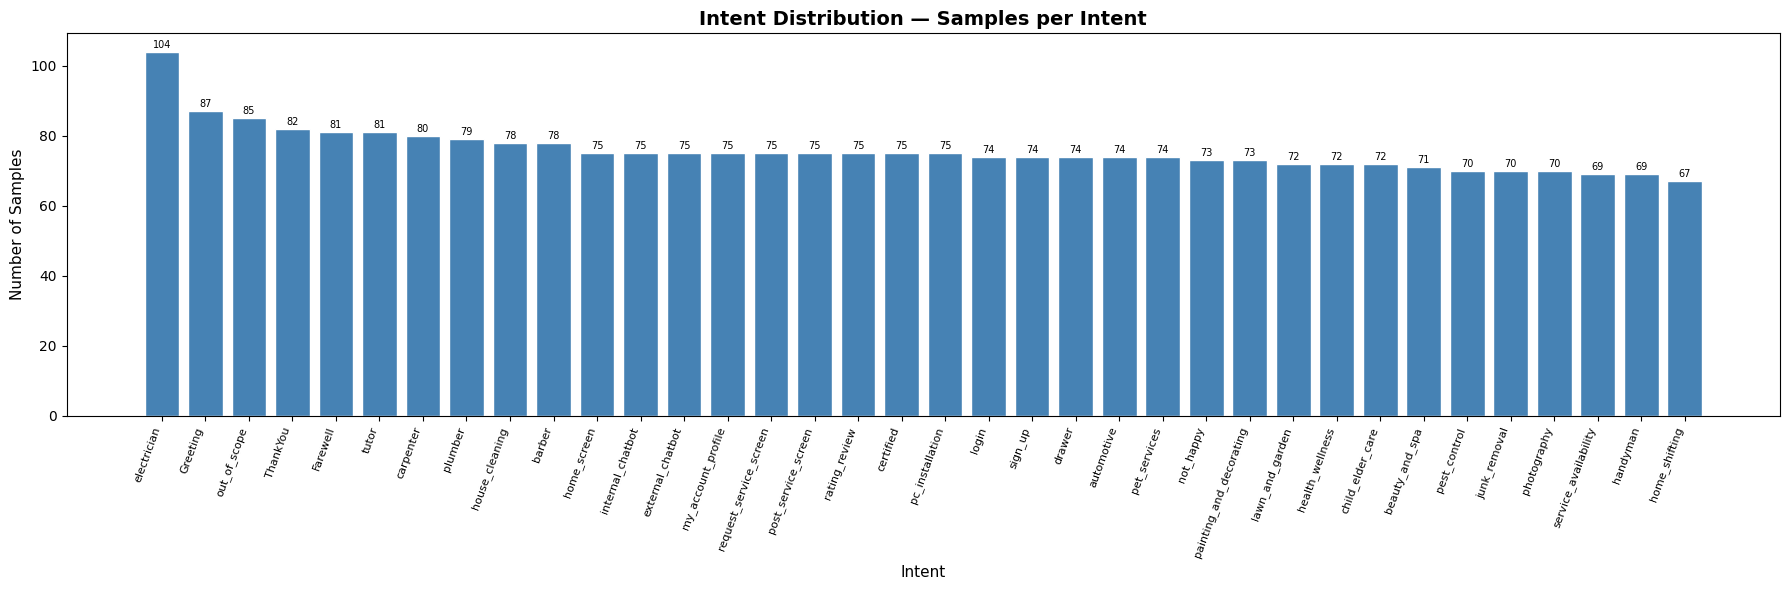

Intent distribution graph saved.


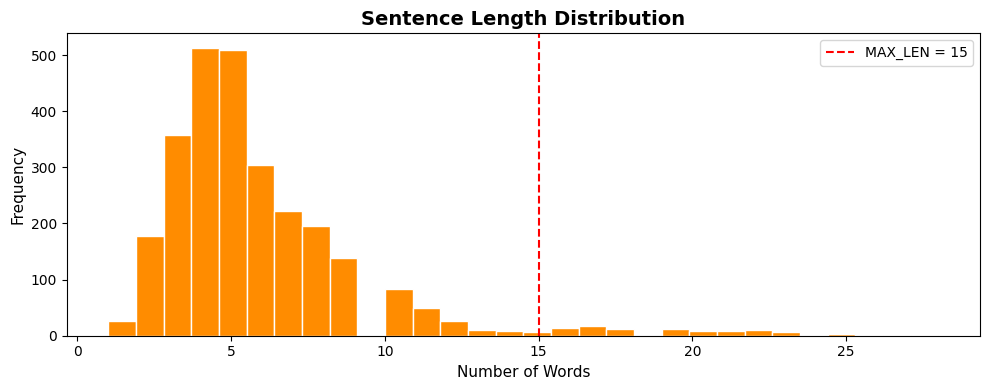

Average sentence length : 5.9 words
Longest sentence        : 28 words
95th percentile         : 12 words
Vocabulary size (actual words found) : 2260
VOCAB_SIZE cap                       : 5000
Input shape                          : (2728, 15)
Number of intent classes : 36
Class list               : [np.str_('Farewell'), np.str_('Greeting'), np.str_('ThankYou'), np.str_('automotive'), np.str_('barber'), np.str_('beauty_and_spa'), np.str_('carpenter'), np.str_('certified'), np.str_('child_elder_care'), np.str_('drawer'), np.str_('electrician'), np.str_('external_chatbot'), np.str_('handyman'), np.str_('health_wellness'), np.str_('home_screen'), np.str_('home_shifting'), np.str_('house_cleaning'), np.str_('internal_chatbot'), np.str_('junk_removal'), np.str_('lawn_and_garden'), np.str_('login'), np.str_('my_account_profile'), np.str_('not_happy'), np.str_('out_of_scope'), np.str_('painting_and_decorating'), np.str_('pc_installation'), np.str_('pest_control'), np.str_('pet_services'), np.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 15, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_layer (Bidirectional)     │ (None, 96)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,380 (1.38 MB)

 Trainable params: 361,380 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

Callbacks configured.
Forcing CPU training to ensure TFLite-compatible GRU kernel...
Epoch 1/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0336 - loss: 3.6422 - val_accuracy: 0.0488 - val_loss: 3.6187 - learning_rate: 0.0010
Epoch 2/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0634 - loss: 3.5800 - val_accuracy: 0.0756 - val_loss: 3.4512 - learning_rate: 0.0010
Epoch 3/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0953 - loss: 3.1778 - val_accuracy: 0.1707 - val_loss: 2.8374 - learning_rate: 0.0010
Epoch 4/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1622 - loss: 2.6940 - val_accuracy: 0.2244 - val_loss: 2.5254 - learning_rate: 0.0010
Epoch 5/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2256 - loss: 2.3959 - val_accuracy: 0.2756 - val_loss: 2.3386 - learning_rate: 0.0010
Epoch 6/80
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2718 - loss: 2.1583 - val_accuracy: 0.3512 - val_loss: 2.1546 - learning_rate: 0.0010
Epoch 7/8

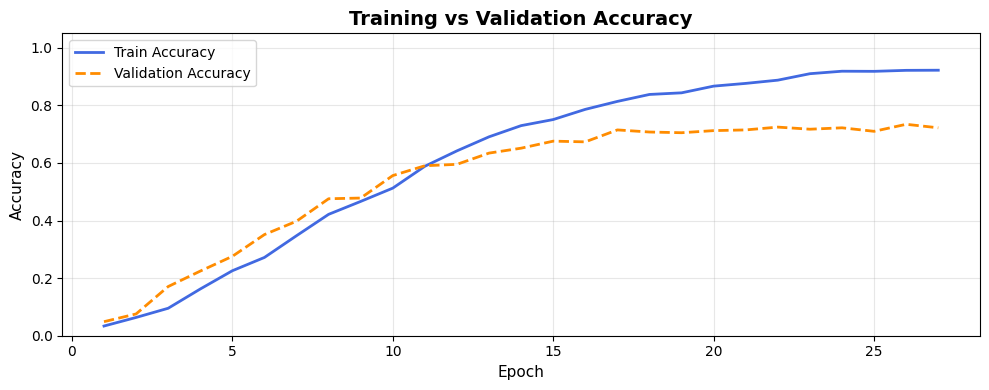

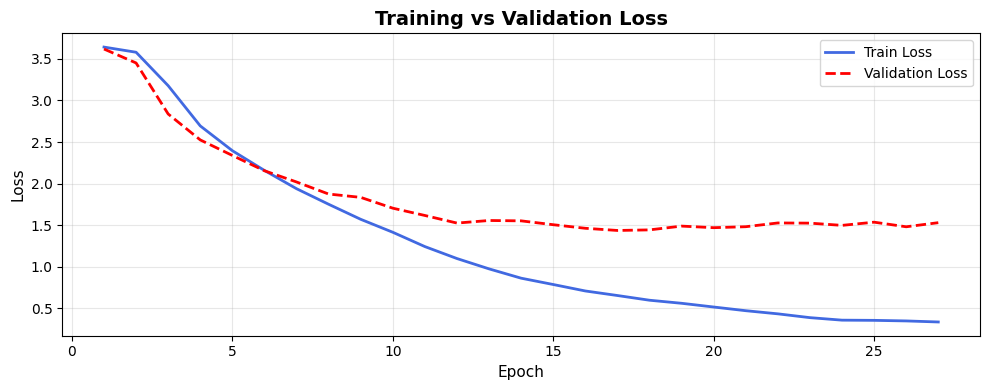

Graphs saved.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
         MODEL EVALUATION RESULTS
  Accuracy  : 71.46%
  Precision : 0.7376
  Recall    : 0.7146
  F1-Score  : 0.7132
                         precision    recall  f1-score   support

               Farewell       0.53      0.83      0.65        12
               Greeting       0.92      0.85      0.88        13
               ThankYou       1.00      0.83      0.91        12
             automotive       0.85      1.00      0.92        11
                 barber       0.88      0.58      0.70        12
         beauty_and_spa       0.69      0.82      0.75        11
              carpenter       0.82      0.75      0.78        12
              certified       0.50      0.82      0.62        11
       child_elder_care       0.54      0.64      0.58        11
                 drawer       0.85      1.00      0.92        11
            electrician       0.90      0.56      0.69        16
       external_chatbot       0.70      0.64   

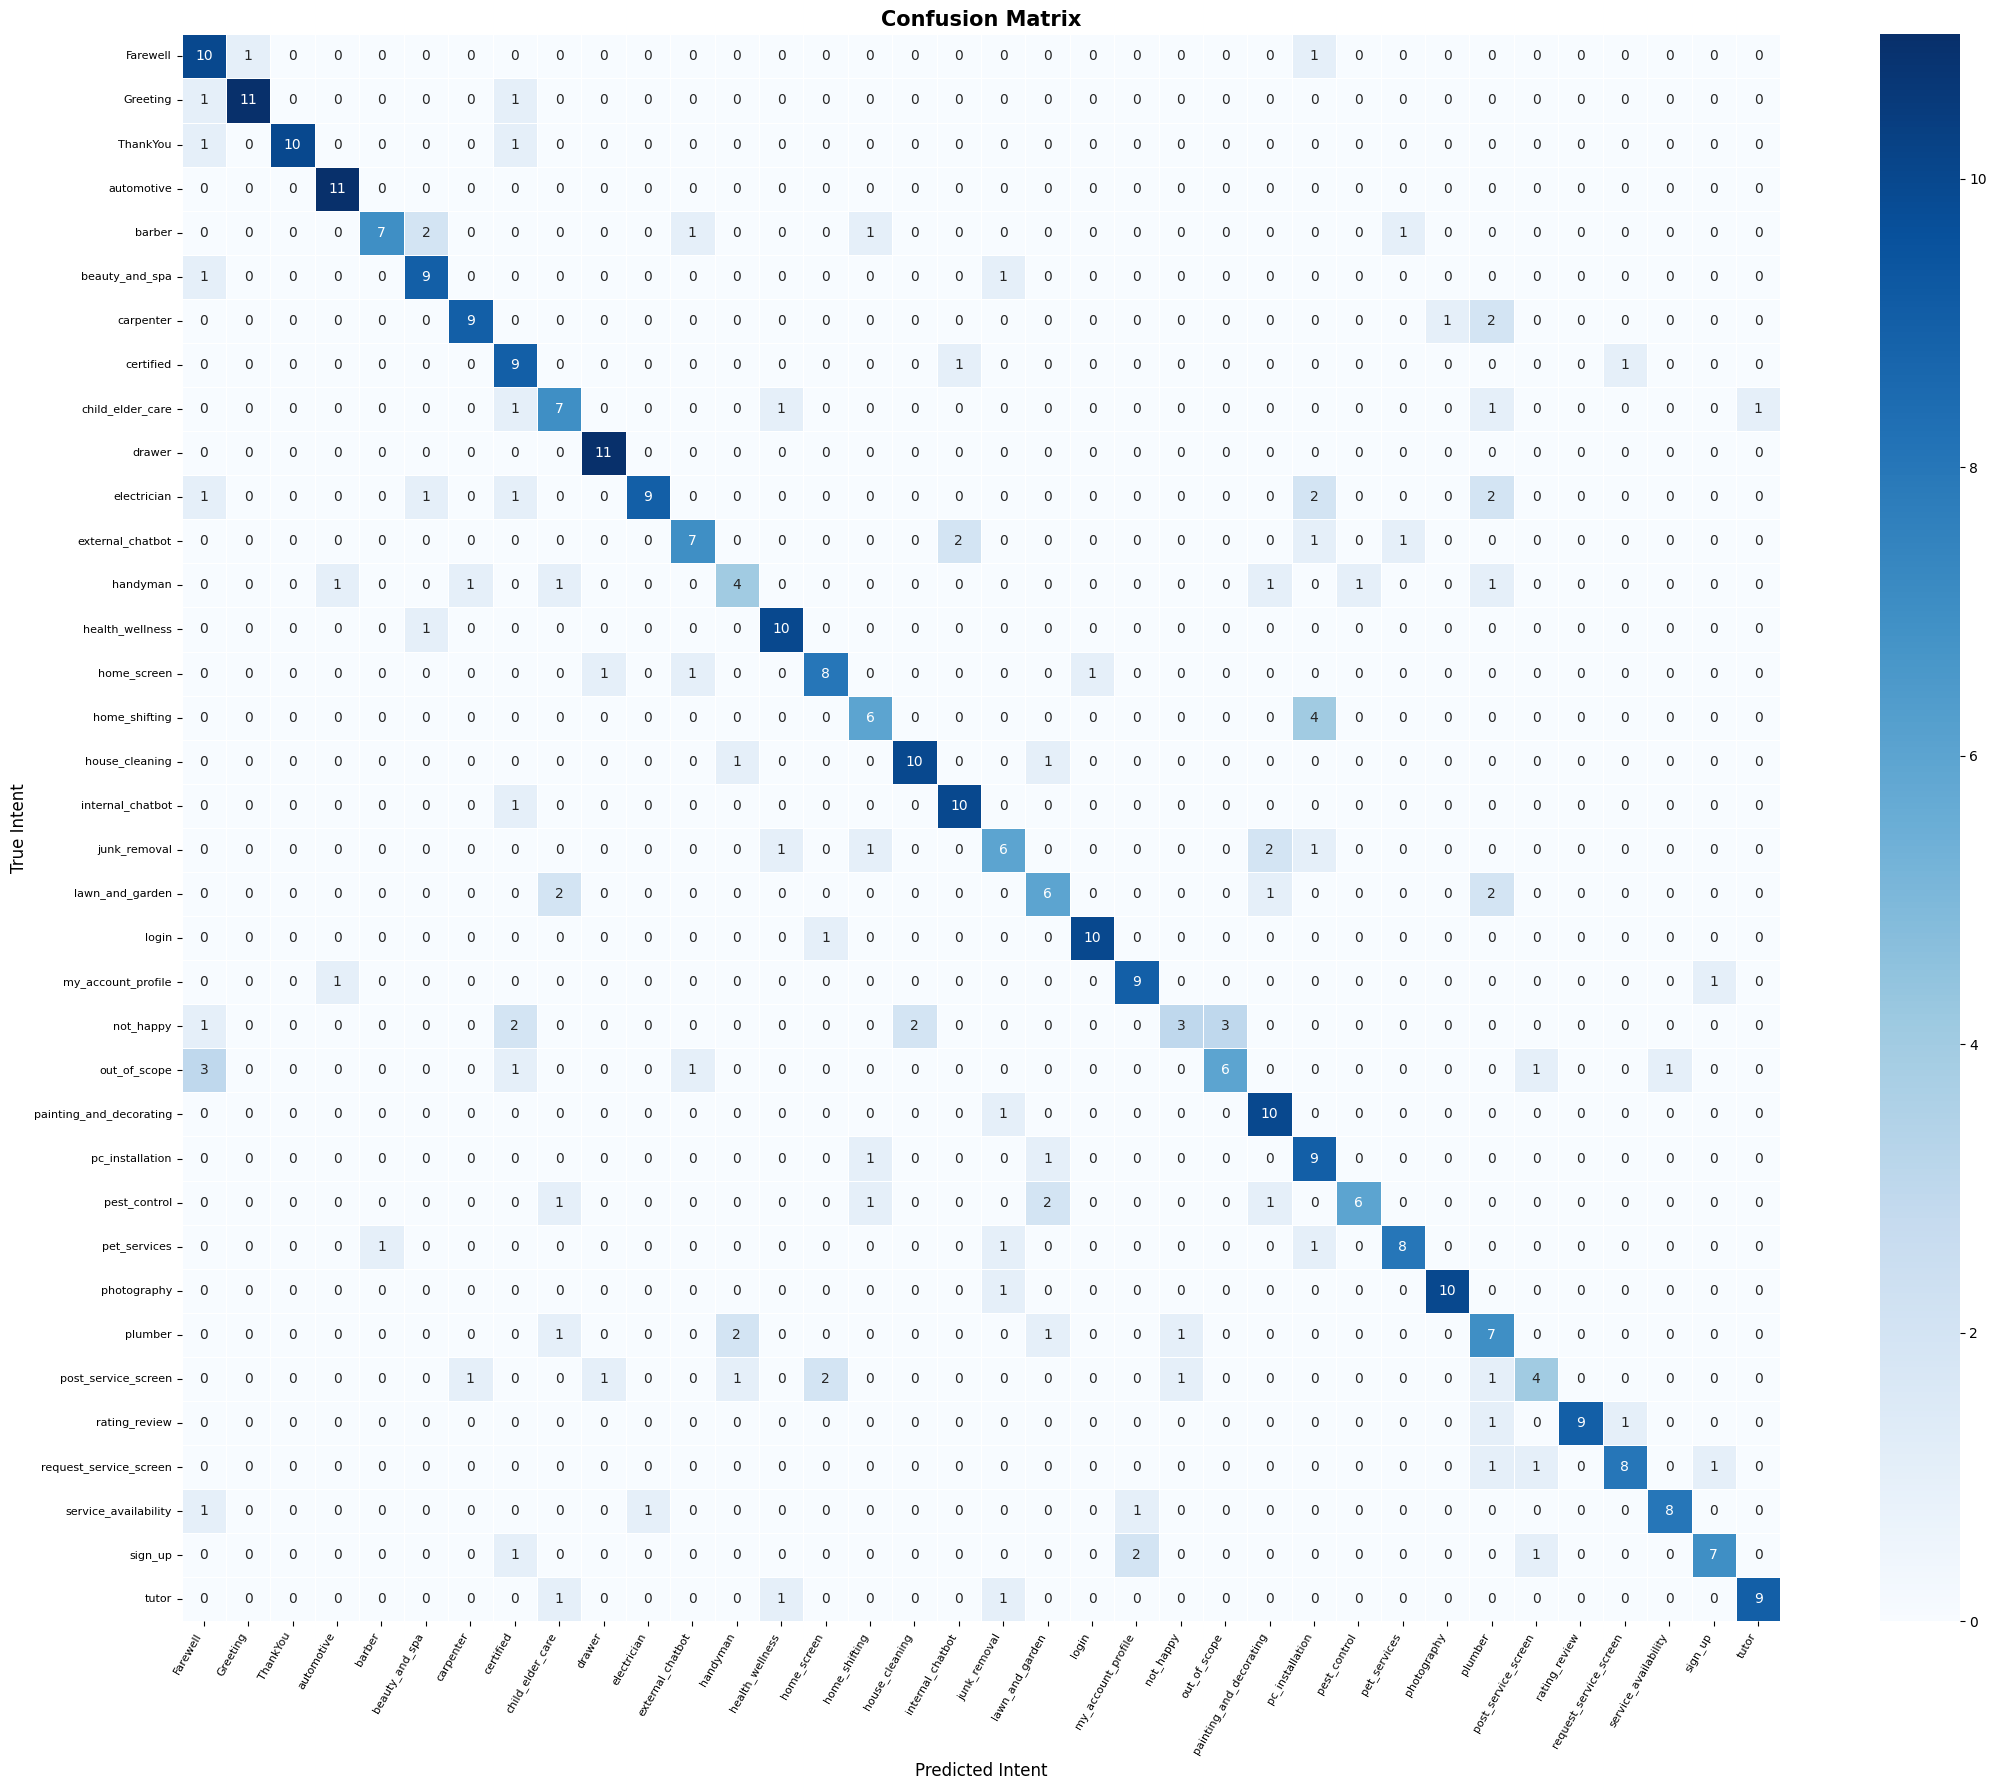

Confusion matrix saved.


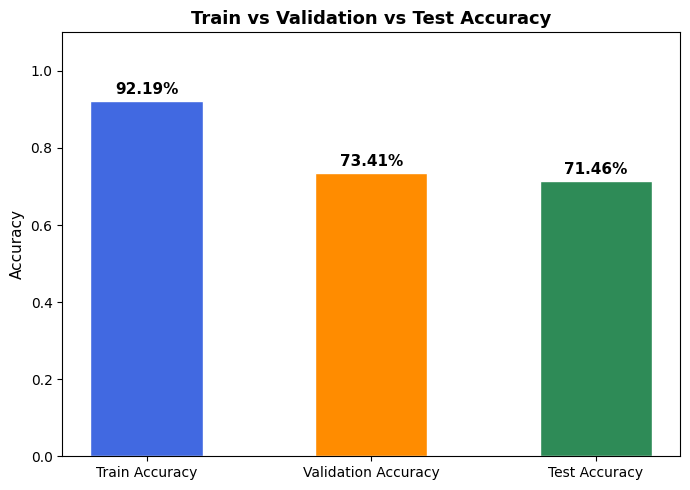

Bar chart saved.

Query                                      Predicted Intent            Conf
I need to login to my account              login                      93.8%
how do I sign up                           sign_up                    82.0%
take me to the home screen                 home_screen                86.2%
open the drawer menu                       drawer                     92.4%
I want to rate the service                 rating_review              93.4%
where is my profile                        out_of_scope               34.7%  ← low
is this a chatbot                          internal_chatbot           59.6%
do you have a WhatsApp bot                 external_chatbot           97.1%
how to post a service                      post_service_screen        81.4%
how to request a service                   request_service_screen     63.1%
my pipe is leaking badly                   plumber                    41.8%
I need someone to clean my house           house_cleaning      

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(fused["CudnnRNNV3:", "sequential_2_1/bigru_layer_1/backward_gru_2_1/CudnnRNNV3@__inference_function_35361"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_35424"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_35424"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(fused["CudnnRNNV3:", "sequential_2_1/bigru_layer_1/backward_gru_2_1/CudnnRNNV3@__inference_function_35361"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_35424"] at fused["

In [3]:
# ============================================================
# SMARTSERVE AI CHATBOT — COMPLETE TRAINING PIPELINE
# TensorFlow 2.20 | Keras 3 | tflite_flutter ^0.11.0
# Run: Runtime → Run all
# ============================================================


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL                                       ║
# ╚══════════════════════════════════════════════════════════╝

# !pip install tensorflow scikit-learn matplotlib seaborn numpy


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — IMPORTS                                       ║
# ╚══════════════════════════════════════════════════════════╝

import json
import re
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, GRU, Dense, Dropout,
)
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — CONFIGURATION                                 ║
# ╚══════════════════════════════════════════════════════════╝

DATA_PATH  = "/content/balanced_dataset_fianl4.json"
OUTPUT_DIR = "smartserve_output"

# VOCAB_SIZE=5000: actual vocab is only 2260 words, 5000 is safe ceiling
VOCAB_SIZE    = 5000

# MAX_LEN=15: dataset 95th-percentile sentence length is 12 words.
# Padding to 30 added pure zeros (noise). 15 captures everything meaningful.
# IMPORTANT: Flutter chatbot_service.dart must also use _maxLen = 15
MAX_LEN       = 15

OOV_TOKEN     = "<OOV>"
EMBEDDING_DIM = 64
DROPOUT_RATE  = 0.4
EPOCHS        = 80     # EarlyStopping will stop early anyway
BATCH_SIZE    = 32
TEST_SIZE     = 0.15
RANDOM_SEED   = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}/")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — LOAD & PREPROCESS                            ║
# ╚══════════════════════════════════════════════════════════╝

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def is_bad_sentence(text):
    words = text.split()
    for i in range(len(words) - 1):
        if words[i] == words[i + 1]:
            return True
    bad_patterns = [
        "can you can you", "i want to i want", "i need i need",
        "please please", "help help", "i want to can you",
        "can you i want",
    ]
    for p in bad_patterns:
        if p in text:
            return True
    return False

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

texts  = []
labels = []

for intent in data["intents"]:
    intent_name = intent["intent"]
    raw_texts   = intent["text"]

    if intent_name == "out_of_scope":
        flat = []
        for item in raw_texts:
            if isinstance(item, list):
                flat.extend(item)
            else:
                flat.append(item)
        raw_texts = flat

    for sentence in raw_texts:
        cleaned = clean_text(str(sentence))
        if cleaned and not is_bad_sentence(cleaned):
            texts.append(cleaned)
            labels.append(intent_name)

# Remove exact duplicates
seen, clean_texts, clean_labels = set(), [], []
for t, l in zip(texts, labels):
    key = (t, l)
    if key not in seen:
        seen.add(key)
        clean_texts.append(t)
        clean_labels.append(l)

texts  = clean_texts
labels = clean_labels

print(f"Total samples after cleaning : {len(texts)}")
print(f"Unique intents               : {len(set(labels))}")
print(f"Intents: {sorted(set(labels))}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — EDA GRAPHS                                    ║
# ╚══════════════════════════════════════════════════════════╝

intent_counts        = Counter(labels)
sorted_intents       = sorted(intent_counts.items(), key=lambda x: -x[1])
intent_names_sorted  = [x[0] for x in sorted_intents]
intent_values_sorted = [x[1] for x in sorted_intents]

plt.figure(figsize=(18, 6))
bars = plt.bar(intent_names_sorted, intent_values_sorted,
               color="steelblue", edgecolor="white")
plt.title("Intent Distribution — Samples per Intent",
          fontsize=14, fontweight="bold")
plt.xlabel("Intent", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)
plt.xticks(rotation=70, ha="right", fontsize=8)
for bar, val in zip(bars, intent_values_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, str(val),
             ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "intent_distribution.png"), dpi=150)
plt.show()
print("Intent distribution graph saved.")

sentence_lengths = [len(t.split()) for t in texts]
plt.figure(figsize=(10, 4))
plt.hist(sentence_lengths, bins=30, color="darkorange", edgecolor="white")
plt.axvline(MAX_LEN, color="red", linestyle="--",
            label=f"MAX_LEN = {MAX_LEN}")
plt.title("Sentence Length Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentence_length_distribution.png"),
            dpi=150)
plt.show()

print(f"Average sentence length : {np.mean(sentence_lengths):.1f} words")
print(f"Longest sentence        : {np.max(sentence_lengths)} words")
print(f"95th percentile         : {np.percentile(sentence_lengths, 95):.0f} words")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — TOKENIZATION & LABEL ENCODING                ║
# ╚══════════════════════════════════════════════════════════╝

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded    = pad_sequences(sequences, maxlen=MAX_LEN,
                          padding="post", truncating="post")

print(f"Vocabulary size (actual words found) : {len(tokenizer.word_index)}")
print(f"VOCAB_SIZE cap                       : {VOCAB_SIZE}")
print(f"Input shape                          : {padded.shape}")

label_encoder  = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes    = len(label_encoder.classes_)

print(f"Number of intent classes : {num_classes}")
print(f"Class list               : {list(label_encoder.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    padded, encoded_labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=encoded_labels,
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print("Cell 6 complete — num_classes, label_encoder, X_train all ready.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — MODEL                                         ║
# ╚══════════════════════════════════════════════════════════╝
# Architecture choices explained:
#
# Bidirectional GRU (48 units):
#   - Reads sentence left→right AND right→left (better context)
#   - 48 units (not 64) — smaller model overfits less on ~77 samples/intent
#   - recurrent_dropout=0 — MUST be 0, TFLite cannot convert recurrent dropout
#   - dropout=0.2 — input/output dropout is safe for TFLite
#
# L2 regularization on Dense:
#   - Penalizes large weights, forces model to generalize
#   - Critical when training data is small
#
# Dropout 0.4 after GRU:
#   - Main defense against the 97% train / 71% val gap we saw before
#
# No input_length= in Embedding:
#   - Deprecated in Keras 3 / TF 2.20, causes UserWarning, removed

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        # input_length intentionally omitted — deprecated in Keras 3
        name="embedding_layer"
    ),

    Bidirectional(
        GRU(
            48,
            dropout=0.2,
            recurrent_dropout=0,    # MUST be 0 — TFLite requirement
            return_sequences=False,
        ),
        name="bigru_layer"
    ),

    Dropout(0.4, name="dropout_1"),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        name="dense_hidden"
    ),

    Dropout(0.3, name="dropout_2"),

    Dense(num_classes, activation="softmax", name="output_layer"),
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — CALLBACKS                                     ║
# ╚══════════════════════════════════════════════════════════╝

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,               # slightly more patience with L2 model
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

print("Callbacks configured.")

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — TRAIN (CPU forced)                            ║
# ╚══════════════════════════════════════════════════════════╝
# WHY CPU? Colab GPU causes TF to use CudnnRNNV3 kernel for GRU.
# CudnnRNNV3 cannot be converted to TFLite — it crashes Cell 16.
# Forcing CPU makes TF use the standard GRU kernel which TFLite
# fully supports. Training is only ~30s slower on this small dataset.

print("Forcing CPU training to ensure TFLite-compatible GRU kernel...")

with tf.device('/CPU:0'):
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

print("\nTraining complete.")
print(f"Final Training Accuracy   : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]*100:.2f}%")
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — TRAINING GRAPHS                              ║
# ╚══════════════════════════════════════════════════════════╝

epochs_ran = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_ran, history.history["accuracy"],
         label="Train Accuracy", color="royalblue", linewidth=2)
plt.plot(epochs_ran, history.history["val_accuracy"],
         label="Validation Accuracy", color="darkorange",
         linewidth=2, linestyle="--")
plt.title("Training vs Validation Accuracy", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.legend(fontsize=10)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_graph.png"), dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_ran, history.history["loss"],
         label="Train Loss", color="royalblue", linewidth=2)
plt.plot(epochs_ran, history.history["val_loss"],
         label="Validation Loss", color="red",
         linewidth=2, linestyle="--")
plt.title("Training vs Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_graph.png"), dpi=150)
plt.show()

print("Graphs saved.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — EVALUATE                                     ║
# ╚══════════════════════════════════════════════════════════╝

y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

test_accuracy  = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred,
                                 average="weighted", zero_division=0)
test_recall    = recall_score(y_test, y_pred,
                              average="weighted", zero_division=0)
test_f1        = f1_score(y_test, y_pred,
                          average="weighted", zero_division=0)

print("=" * 50)
print("         MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {test_accuracy*100:.2f}%")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1-Score  : {test_f1:.4f}")
print("=" * 50)

print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

report_text = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
)
with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(f"Accuracy  : {test_accuracy:.4f}\n")
    f.write(f"Precision : {test_precision:.4f}\n")
    f.write(f"Recall    : {test_recall:.4f}\n")
    f.write(f"F1-Score  : {test_f1:.4f}\n\n")
    f.write(report_text)

print("Classification report saved.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — CONFUSION MATRIX                             ║
# ╚══════════════════════════════════════════════════════════╝

cm          = confusion_matrix(y_test, y_pred)
class_names = label_encoder.classes_

plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title("Confusion Matrix", fontsize=15, fontweight="bold")
plt.ylabel("True Intent", fontsize=12)
plt.xlabel("Predicted Intent", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Confusion matrix saved.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — ACCURACY BAR CHART                           ║
# ╚══════════════════════════════════════════════════════════╝

best_train_acc = max(history.history["accuracy"])
best_val_acc   = max(history.history["val_accuracy"])

categories = ["Train Accuracy", "Validation Accuracy", "Test Accuracy"]
values     = [best_train_acc, best_val_acc, test_accuracy]
colors     = ["royalblue", "darkorange", "seagreen"]

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, values, color=colors,
               edgecolor="white", width=0.5)
plt.ylim(0, 1.1)
plt.title("Train vs Validation vs Test Accuracy",
          fontsize=13, fontweight="bold")
plt.ylabel("Accuracy", fontsize=11)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val*100:.2f}%",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_comparison_bar.png"), dpi=150)
plt.show()
print("Bar chart saved.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 14 — SAMPLE PREDICTIONS                           ║
# ╚══════════════════════════════════════════════════════════╝

def predict_intent(text, threshold=0.40):
    cleaned   = clean_text(text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded_in = pad_sequences(seq, maxlen=MAX_LEN,
                              padding="post", truncating="post")
    probs      = model.predict(padded_in, verbose=0)[0]
    top_idx    = np.argmax(probs)
    confidence = float(probs[top_idx])
    intent_name = label_encoder.classes_[top_idx]
    if confidence < threshold:
        return "out_of_scope", confidence, False
    return intent_name, confidence, True

test_queries = [
    "I need to login to my account", "how do I sign up",
    "take me to the home screen", "open the drawer menu",
    "I want to rate the service", "where is my profile",
    "is this a chatbot", "do you have a WhatsApp bot",
    "how to post a service", "how to request a service",
    "my pipe is leaking badly", "I need someone to clean my house",
    "my lights are not working", "need a carpenter for door repair",
    "book a barber at home", "my car won't start",
    "pest control for cockroaches", "mujhe ghar safai chahiye",
    "bache ke liye tutor chahiye", "painter chahiye ghar ke liye",
    "tell me a joke", "who is the prime minister",
    "play a song", "what is the weather today",
]

print("\n" + "=" * 75)
print(f"{'Query':<42} {'Predicted Intent':<25} {'Conf':>6}")
print("=" * 75)
for query in test_queries:
    intent, conf, passed = predict_intent(query)
    flag = "" if passed else "  ← low"
    print(f"{query:<42} {intent:<25} {conf*100:>5.1f}%{flag}")
print("=" * 75)


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 15 — SAVE KERAS BACKUP                            ║
# ╚══════════════════════════════════════════════════════════╝

before_dir = os.path.join(OUTPUT_DIR, "model_before_tflite")
os.makedirs(before_dir, exist_ok=True)

# Save in native .keras format (H5 is legacy in TF2.20)
model.save(os.path.join(before_dir, "smartserve_model.keras"))

with open(os.path.join(before_dir, "tokenizer.json"), "w",
          encoding="utf-8") as f:
    f.write(tokenizer.to_json())

with open(os.path.join(before_dir, "classes.txt"), "w",
          encoding="utf-8") as f:
    for cls in label_encoder.classes_:
        f.write(cls + "\n")

intent_responses = {}
for intent in data["intents"]:
    if "responses" in intent:
        intent_responses[intent["intent"]] = intent["responses"]

with open(os.path.join(before_dir, "intent_responses.json"), "w",
          encoding="utf-8") as f:
    json.dump(intent_responses, f, indent=2, ensure_ascii=False)

config = {"MAX_LEN": MAX_LEN, "VOCAB_SIZE": VOCAB_SIZE,
          "num_classes": num_classes}
with open(os.path.join(before_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

shutil.make_archive(
    os.path.join(OUTPUT_DIR, "smartserve_before_tflite"),
    "zip", before_dir,
)
print("Keras backup saved.")

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 16 — TFLITE CONVERSION                            ║
# ║  Fixed for TF 2.20 + Keras 3 + GPU Colab               ║
# ╚══════════════════════════════════════════════════════════╝
# Previous error: CudnnRNNV3 op cannot be converted to TFLite.
# Fix: re-build the model architecture on CPU, load trained
#      weights into it, then convert from that CPU model.
#      This guarantees the standard GRU kernel is used.

import numpy as np

tflite_dir = os.path.join(OUTPUT_DIR, "tflite_package")
os.makedirs(tflite_dir, exist_ok=True)

# ── Step 1: Build a fresh CPU model with same architecture ─
# We rebuild on CPU so TF uses standard GRU (not CudnnRNNV3).
# Then we copy the trained weights into it.
print("Rebuilding model on CPU for TFLite conversion...")

with tf.device('/CPU:0'):
    cpu_model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            name="embedding_layer"
        ),
        Bidirectional(
            GRU(
                48,
                dropout=0.2,
                recurrent_dropout=0,
                return_sequences=False,
                # implementation=1 forces standard kernel, not CuDNN
                implementation=1,
            ),
            name="bigru_layer"
        ),
        Dropout(0.4, name="dropout_1"),
        Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
            name="dense_hidden"
        ),
        Dropout(0.3, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output_layer"),
    ])
    cpu_model.build(input_shape=(None, MAX_LEN))

# ── Step 2: Copy trained weights into CPU model ────────────
# model.get_weights() returns numpy arrays — device-agnostic.
cpu_model.set_weights(model.get_weights())
print("Trained weights copied to CPU model.")

# ── Step 3: Save CPU model as .keras and reload clean ──────
cpu_keras_path = os.path.join(OUTPUT_DIR, "smartserve_cpu_model.keras")

with tf.device('/CPU:0'):
    cpu_model.save(cpu_keras_path)

print(f"CPU model saved: {cpu_keras_path}")

# Must reload to get a clean SavedModel graph before conversion
with tf.device('/CPU:0'):
    loaded_model = tf.keras.models.load_model(cpu_keras_path)

print("CPU model reloaded cleanly.")

# ── Step 4: Convert ────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]

converter.optimizations = []
converter._experimental_lower_tensor_list_ops = False

print("Converting to TFLite...")
tflite_model = converter.convert()
print("Conversion successful.")

# ── Step 5: Save .tflite ──────────────────────────────────
tflite_path = os.path.join(tflite_dir, "smartserve_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"TFLite model: {os.path.getsize(tflite_path)/1024:.1f} KB")

# ── Step 6: Inspect tensors ───────────────────────────────
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

print("\n--- TFLite Tensor Details (Flutter MUST match exactly) ---")
print(f"Input  shape : {inp['shape']}")    # [1, 15]
print(f"Input  dtype : {inp['dtype']}")    # float32
print(f"Output shape : {out['shape']}")    # [1, 36]
print(f"Output dtype : {out['dtype']}")    # float32

INPUT_NUMPY_DTYPE = np.float32 if inp['dtype'] == np.float32 else np.int32
FLUTTER_DTYPE     = "float32"  if inp['dtype'] == np.float32 else "int32"

print(f"\n>>> Flutter input dtype : {FLUTTER_DTYPE} <<<")
print(f">>> Use {'Float32List' if FLUTTER_DTYPE == 'float32' else 'Int32List'} in chatbot_service.dart <<<")

# ── Step 7: Verify ────────────────────────────────────────
test_q   = "my pipe is leaking"
cleaned  = clean_text(test_q)
seq      = tokenizer.texts_to_sequences([cleaned])
padded_v = pad_sequences(seq, maxlen=MAX_LEN,
                         padding="post", truncating="post")

input_arr = padded_v.astype(INPUT_NUMPY_DTYPE)
interpreter.set_tensor(inp["index"], input_arr)
interpreter.invoke()

probs       = interpreter.get_tensor(out["index"])[0]
pred_idx    = np.argmax(probs)
pred_intent = label_encoder.classes_[pred_idx]
pred_conf   = float(probs[pred_idx])

print(f"\nVerification: '{test_q}'")
print(f"  Predicted : {pred_intent}  ({pred_conf*100:.1f}%)")
print(f"  Expected  : plumber")
print(f"  {'PASS' if pred_intent == 'plumber' else 'FAIL - check weights copy'}")

# ── Step 8: Save Flutter asset files ─────────────────────
with open(os.path.join(tflite_dir, "tokenizer.json"), "w",
          encoding="utf-8") as f:
    f.write(tokenizer.to_json())

with open(os.path.join(tflite_dir, "classes.txt"), "w",
          encoding="utf-8") as f:
    for cls in label_encoder.classes_:
        f.write(cls + "\n")

intent_responses = {}
for intent in data["intents"]:
    if "responses" in intent:
        intent_responses[intent["intent"]] = intent["responses"]

with open(os.path.join(tflite_dir, "intent_responses.json"), "w",
          encoding="utf-8") as f:
    json.dump(intent_responses, f, indent=2, ensure_ascii=False)

config_flutter = {
    "MAX_LEN"     : MAX_LEN,
    "VOCAB_SIZE"  : VOCAB_SIZE,
    "num_classes" : num_classes,
    "input_dtype" : FLUTTER_DTYPE,
    "output_dtype": "float32",
    "threshold"   : 0.40,
}
with open(os.path.join(tflite_dir, "config.json"), "w") as f:
    json.dump(config_flutter, f, indent=2)

shutil.make_archive(
    os.path.join(OUTPUT_DIR, "smartserve_tflite_package"),
    "zip", tflite_dir,
)

print("\nFiles ready (copy all to assets/chatbot/):")
for fname in sorted(os.listdir(tflite_dir)):
    fsize = os.path.getsize(os.path.join(tflite_dir, fname))
    print(f"  {fname:<40} {fsize/1024:.1f} KB")
print("\nDownload: smartserve_tflite_package.zip")

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 17 — FINAL SUMMARY                                ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "=" * 55)
print("       SMARTSERVE AI — TRAINING COMPLETE")
print("=" * 55)
print(f"  Training samples   : {len(X_train)}")
print(f"  Test samples       : {len(X_test)}")
print(f"  Intent classes     : {num_classes}")
print(f"  Epochs ran         : {len(history.history['accuracy'])}")
print(f"  Best train acc     : {max(history.history['accuracy'])*100:.2f}%")
print(f"  Best val acc       : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"  Final test acc     : {test_accuracy*100:.2f}%")
print(f"  F1-Score           : {test_f1:.4f}")
print(f"  TFLite input dtype : {FLUTTER_DTYPE}")
print(f"  MAX_LEN            : {MAX_LEN}")
print("=" * 55)
print("\nStep 1: Download smartserve_tflite_package.zip")
print("Step 2: Extract and copy all files to Flutter assets/chatbot/")
print(f"Step 3: In chatbot_service.dart set _maxLen = {MAX_LEN}")
print(f"Step 4: Use {'Float32List' if FLUTTER_DTYPE == 'float32' else 'Int32List'} for TFLite input")